<div style="background:linear-gradient(135deg,#0d1117 0%,#161b22 60%,#1c2128 100%);padding:50px 40px;border-radius:16px;border-left:6px solid #e74c3c;margin-bottom:20px;">
  <h1 style="color:#ffffff;font-size:2.2em;margin:0 0 10px 0;">Modelo ML — Prediccion de Incidentes GUB por Barrio</h1>
  <p style="color:#8b949e;font-size:1.05em;margin:0 0 20px 0;">Notebook 10 · Proyecto Final Bootcamp · Criminalistica Catalunya 2010-2025</p>
  <div style="display:flex;flex-wrap:wrap;gap:12px;">
    <div style="background:#21262d;padding:12px 20px;border-radius:8px;border-left:3px solid #e74c3c;">
      <span style="color:#8b949e;font-size:0.85em;">Input</span><br/>
      <span style="color:#fff;font-size:1em;">data/clean/features_ml.csv</span>
    </div>
    <div style="background:#21262d;padding:12px 20px;border-radius:8px;border-left:3px solid #e74c3c;">
      <span style="color:#8b949e;font-size:0.85em;">Target</span><br/>
      <span style="color:#fff;font-size:1em;">num_incidents (barri x mes)</span>
    </div>
    <div style="background:#21262d;padding:12px 20px;border-radius:8px;border-left:3px solid #27ae60;">
      <span style="color:#8b949e;font-size:0.85em;">Train</span><br/>
      <span style="color:#fff;font-size:1em;">2015 - 2022</span>
    </div>
    <div style="background:#21262d;padding:12px 20px;border-radius:8px;border-left:3px solid #f39c12;">
      <span style="color:#8b949e;font-size:0.85em;">Test</span><br/>
      <span style="color:#fff;font-size:1em;">2023 - 2024</span>
    </div>
    <div style="background:#21262d;padding:12px 20px;border-radius:8px;border-left:3px solid #9b59b6;">
      <span style="color:#8b949e;font-size:0.85em;">Modelos</span><br/>
      <span style="color:#fff;font-size:1em;">Random Forest · XGBoost · Prophet</span>
    </div>
  </div>
  <p style="color:#6e7681;font-size:0.9em;margin:20px 0 0 0;">Generado 2026-06-05 · Fuente: GUB Barcelona / OSM / INE / Idescat · 74 barris · 2010-2025</p>
</div>

## Librerias instaladas en este notebook

| Libreria | Para que se usa |
|---|---|
| **xgboost** | XGBRegressor — gradient boosting, comparativa con Random Forest, maneja NaN nativamente |
| **prophet** | Modelo de series temporales de Facebook, maneja no-estacionariedad y estacionalidad sin d=1 |

In [1]:
import subprocess, sys

libs = {
    'xgboost': 'XGBRegressor — gradient boosting, comparativa con RF',
    'prophet': 'Series temporales con estacionalidad — forecast 2025-2026',
}

for pkg, desc in libs.items():
    try:
        __import__(pkg)
        print(f'[OK] {pkg:<15s} ya instalado')
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'[OK] {pkg:<15s} instalado')

print('Paquetes listos.')

[OK] xgboost         ya instalado


[OK] prophet         ya instalado
Paquetes listos.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error
)

sns.set_theme(style='whitegrid', palette='muted')
pd.options.display.max_columns = 30

DATA_PATH = '../data/clean/'

print('[OK] Imports completados.')

[OK] Imports completados.


In [3]:
df_raw = pd.read_csv(DATA_PATH + 'features_ml.csv')

print(f'Shape raw (tipo x barri x mes): {df_raw.shape}')
print(f'Columnas: {list(df_raw.columns)}')
print(f'Rango temporal: {df_raw["anyo"].min()} - {df_raw["anyo"].max()}')
print(f'Barrios unicos: {df_raw["id_territorio"].nunique()}')
print()

# El CSV viene a nivel tipo_incident x barri x mes (= fact_incidentes_gub con features unidas)
# Media de tipos por barri-mes:
combos = df_raw.groupby(['id_territorio', 'anyo', 'mes']).size()
print(f'Combinaciones barri x mes unicas: {len(combos)}')
print(f'Media tipos de incidente por barri-mes: {df_raw.shape[0] / len(combos):.1f}')
df_raw.head(3)

Shape raw (tipo x barri x mes): (543709, 21)
Columnas: ['id_territorio', 'nom_barri', 'nom_districte', 'fecha', 'anyo', 'mes', 'num_incidents', 'lag_1', 'lag_12', 'mes_sin', 'mes_cos', 'renta_barri', 'pct_baja_edu', 'n_ocio', 'n_turismo', 'n_comercio', 'n_transport', 'afluencia_total', 'lat', 'lon', 'cluster']
Rango temporal: 2010 - 2025
Barrios unicos: 74

Combinaciones barri x mes unicas: 14184
Media tipos de incidente por barri-mes: 38.3


,id_territorio,nom_barri,nom_districte,fecha,anyo,mes,num_incidents,lag_1,lag_12,mes_sin,mes_cos,renta_barri,pct_baja_edu,n_ocio,n_turismo,n_comercio,n_transport,afluencia_total,lat,lon,cluster
0,63,el Guinardó,Horta-Guinardó,2010-01-01,2010,1,2,NaN,NaN,0.5,0.866025,NaN,NaN,65.0,6.0,57.0,121.0,249.0,41.41882,2.173626,0.0
1,63,el Guinardó,Horta-Guinardó,2010-01-01,2010,1,1,2.0,NaN,0.5,0.866025,NaN,NaN,65.0,6.0,57.0,121.0,249.0,41.41882,2.173626,0.0
2,63,el Guinardó,Horta-Guinardó,2010-01-01,2010,1,1,1.0,NaN,0.5,0.866025,NaN,NaN,65.0,6.0,57.0,121.0,249.0,41.41882,2.173626,0.0


---
## S1 · Preparacion de datos

El CSV `features_ml.csv` esta a nivel **tipo_incidente × barri × mes** (543.709 filas = igual que `fact_incidentes_gub`).  
Para el modelo de prediccion de criminalidad a nivel de barrio necesitamos **una fila por barri × mes** (suma de todos los tipos de incidente).

**Pipeline:**
1. Agregar `num_incidents` por (barri, mes) sumando todos los tipos
2. Mantener features a nivel barri (primera observacion por grupo, son estaticas o de baja variacion)
3. Recomputar `lag_1` y `lag_12` sobre el total agregado
4. Imputar nulls: bfill/ffill dentro de cada barrio, luego mediana global
5. Definir matrix de features FEAT_COLS y target TARGET

In [4]:
BARRI_FEATS = ['renta_barri', 'pct_baja_edu', 'n_ocio', 'n_turismo',
               'n_comercio', 'n_transport', 'afluencia_total', 'lat', 'lon', 'cluster']

agg_dict = {'num_incidents': 'sum'}
for feat in BARRI_FEATS:
    agg_dict[feat] = 'first'

df = (
    df_raw
    .groupby(['id_territorio', 'nom_barri', 'nom_districte', 'fecha', 'anyo', 'mes'],
             as_index=False)
    .agg(agg_dict)
)
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.sort_values(['id_territorio', 'fecha']).reset_index(drop=True)

n_barrios  = df['id_territorio'].nunique()
n_meses    = df['fecha'].nunique()
print(f'Shape agregado: {df.shape}  ({n_barrios} barrios x {n_meses} meses)')
print(f'Rango: {df["fecha"].min().date()} a {df["fecha"].max().date()}')
print(f'Target (total incidentes): min={df["num_incidents"].min()}, '
      f'media={df["num_incidents"].mean():.1f}, max={df["num_incidents"].max()}')
df[['nom_barri', 'fecha', 'num_incidents'] + BARRI_FEATS[:4]].head(4)

Shape agregado: (14184, 17)  (74 barrios x 192 meses)
Rango: 2010-01-01 a 2025-12-01
Target (total incidentes): min=5, media=421.0, max=4420


,nom_barri,fecha,num_incidents,renta_barri,pct_baja_edu,n_ocio,n_turismo
0,el Guinardó,2010-01-01,358,NaN,NaN,65.0,6.0
1,el Guinardó,2010-02-01,316,NaN,NaN,65.0,6.0
2,el Guinardó,2010-03-01,355,NaN,NaN,65.0,6.0
3,el Guinardó,2010-04-01,278,NaN,NaN,65.0,6.0


In [5]:
# Recompute lags al nivel barri x mes (no tipo)
df['lag_1']  = df.groupby('id_territorio')['num_incidents'].shift(1)
df['lag_12'] = df.groupby('id_territorio')['num_incidents'].shift(12)

# Estacionalidad ciclica
df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12)

# Imputacion: pct_baja_edu solo disponible desde 2021 -> bfill propaga 2021 hacia atras
# renta_barri disponible 2015-2023 -> ffill para 2024-2025
for col in ['renta_barri', 'pct_baja_edu', 'afluencia_total', 'n_ocio', 'n_turismo',
            'n_comercio', 'n_transport', 'lat', 'lon']:
    df[col] = df.groupby('id_territorio')[col].transform(lambda x: x.bfill().ffill())
    # Fallback: mediana global para los 2 barrios sin datos OSM
    df[col] = df[col].fillna(df[col].median())

# cluster: int (0, 1, 2, ...) con fallback 0
df['cluster'] = df.groupby('id_territorio')['cluster'].transform(lambda x: x.bfill().ffill())
df['cluster'] = df['cluster'].fillna(0).astype(int)

print('Nulls tras imputacion:')
cols_check = ['lag_1', 'lag_12', 'renta_barri', 'pct_baja_edu',
              'afluencia_total', 'lat', 'lon', 'cluster', 'num_incidents']
nulls_post = df[cols_check].isnull().sum()
print(nulls_post[nulls_post > 0].to_string() if nulls_post.any() else '  Ningun null en columnas clave.')

Nulls tras imputacion:


lag_1      74
lag_12    888


In [6]:
FEAT_COLS = ['lag_1', 'lag_12', 'mes_sin', 'mes_cos', 'anyo',
             'renta_barri', 'pct_baja_edu', 'afluencia_total',
             'n_ocio', 'n_transport', 'cluster', 'lat', 'lon']
TARGET = 'num_incidents'

tabla_feats = pd.DataFrame([
    ('lag_1',           'Autorregresivo', 'fact_incidentes_gub', 'barri x mes', 'Incidentes mes anterior (T-1)'),
    ('lag_12',          'Autorregresivo', 'fact_incidentes_gub', 'barri x mes', 'Incidentes mismo mes ano anterior (T-12)'),
    ('mes_sin',         'Temporal',       'dim_tiempo',          'mensual',     'Estacionalidad ciclica — seno'),
    ('mes_cos',         'Temporal',       'dim_tiempo',          'mensual',     'Estacionalidad ciclica — coseno'),
    ('anyo',            'Temporal',       'dim_tiempo',          'anual',       'Tendencia lineal'),
    ('renta_barri',     'Socioeconomico', 'ctx_renta_barri',     'barri x ano', '2015-2023, bfill/ffill'),
    ('pct_baja_edu',    'Socioeconomico', 'ctx_socioeconomico',  'barri x ano', 'Pct educacion baja (2021-2023, bfill)'),
    ('afluencia_total', 'Afluencia',      'osm_afluencia_barri', 'barri',       'Total POIs OSM — proxy trafico personas'),
    ('n_ocio',          'Afluencia',      'osm_afluencia_barri', 'barri',       'Bares / restaurantes / pubs'),
    ('n_transport',     'Afluencia',      'osm_afluencia_barri', 'barri',       'Paradas metro / bus / tren'),
    ('cluster',         'Espacial',       'K-Means nb09 S5',     'barri',       'Perfil urbano (categorica)'),
    ('lat',             'Espacial',       'geo_territorio',      'barri',       'Centroide WGS84'),
    ('lon',             'Espacial',       'geo_territorio',      'barri',       'Centroide WGS84'),
], columns=['Feature', 'Tipo', 'Fuente', 'Granularidad', 'Notas'])

print(f'Target: {TARGET}')
print(f'Features ({len(FEAT_COLS)}): {FEAT_COLS}')
print()
tabla_feats.style.set_properties(**{'text-align': 'left'})

Target: num_incidents
Features (13): ['lag_1', 'lag_12', 'mes_sin', 'mes_cos', 'anyo', 'renta_barri', 'pct_baja_edu', 'afluencia_total', 'n_ocio', 'n_transport', 'cluster', 'lat', 'lon']



,Feature,Tipo,Fuente,Granularidad,Notas
0,lag_1,Autorregresivo,fact_incidentes_gub,barri x mes,Incidentes mes anterior (T-1)
1,lag_12,Autorregresivo,fact_incidentes_gub,barri x mes,Incidentes mismo mes ano anterior (T-12)
2,mes_sin,Temporal,dim_tiempo,mensual,Estacionalidad ciclica — seno
3,mes_cos,Temporal,dim_tiempo,mensual,Estacionalidad ciclica — coseno
4,anyo,Temporal,dim_tiempo,anual,Tendencia lineal
5,renta_barri,Socioeconomico,ctx_renta_barri,barri x ano,"2015-2023, bfill/ffill"
6,pct_baja_edu,Socioeconomico,ctx_socioeconomico,barri x ano,"Pct educacion baja (2021-2023, bfill)"
7,afluencia_total,Afluencia,osm_afluencia_barri,barri,Total POIs OSM — proxy trafico personas
8,n_ocio,Afluencia,osm_afluencia_barri,barri,Bares / restaurantes / pubs
9,n_transport,Afluencia,osm_afluencia_barri,barri,Paradas metro / bus / tren


<div style="background:#1c2128;padding:16px 20px;border-radius:8px;border-left:4px solid #27ae60;margin:10px 0;">
<b style="color:#27ae60;">Hallazgo S1 — Datos preparados</b><br/>
<ul style="color:#c9d1d9;margin:8px 0 0 0;">
<li>14.184 filas barri x mes (74 barrios, 192 meses 2010-2025).</li>
<li><b>pct_baja_edu</b>: solo disponible desde 2021 en ctx_socioeconomico. Tras bfill, propaga el valor 2021 hacia atras (2010-2020). Limitacion: asume nivel educativo estable en la decada — razonable para granularidad de barrio.</li>
<li><b>renta_barri</b>: disponible 2015-2023. Train 2015-2022 tiene cobertura completa; 2024-2025 se extiende con ffill.</li>
<li><b>afluencia_total / lat / lon</b>: 2 barrios perifericos sin geometria OSM — imputados con mediana global.</li>
<li>Nota metodologica (nb09 S3): lag_1 y lag_12 son los predictores mas fuertes. afluencia_total domina sobre renta/edu en incidentes absolutos (OLS R2=0.791). Usar afluencia_total, NO n_ocio+n_comercio por separado (VIF &gt; 8).</li>
</ul>
</div>

---
## S2 · Split temporal + Baseline

**Ventana de entrenamiento:** 2015-2022 (donde `renta_barri` esta disponible).  
**Ventana de test:** 2023-2024 (datos recientes, fuera del periodo de entrenamiento).  
**Sin shuffle** — se respeta el orden temporal para evitar data leakage.

**Baseline naive:** predecir el valor del mes anterior (`lag_1`). Si el modelo ML no mejora el baseline, no aporta valor.

In [7]:
# Split temporal: respetar orden, sin shuffle
train_mask = (df['anyo'] >= 2015) & (df['anyo'] <= 2022)
test_mask  = (df['anyo'] >= 2023) & (df['anyo'] <= 2024)

# Dropna solo en columnas que usara el modelo (lags generan NaN en primeros meses)
KEY_COLS = ['lag_1', 'lag_12'] + FEAT_COLS
train = df[train_mask].dropna(subset=KEY_COLS).copy()
test  = df[test_mask].dropna(subset=KEY_COLS).copy()

X_train, y_train = train[FEAT_COLS].values, train[TARGET].values
X_test,  y_test  = test[FEAT_COLS].values,  test[TARGET].values

print(f'Train: {X_train.shape}  | {train["anyo"].min()}-{train["anyo"].max()} | {train["id_territorio"].nunique()} barrios')
print(f'Test:  {X_test.shape}   | {test["anyo"].min()}-{test["anyo"].max()} | {test["id_territorio"].nunique()} barrios')
print()

# Baseline: predecir lag_1 en test
y_baseline = test['lag_1'].values
mae_b   = mean_absolute_error(y_test, y_baseline)
rmse_b  = np.sqrt(mean_squared_error(y_test, y_baseline))
r2_b    = r2_score(y_test, y_baseline)
# MAPE: clip y_true a 1 para evitar div/0 en barrios casi vacios
mape_b  = mean_absolute_percentage_error(np.clip(y_test, 1, None), np.clip(y_baseline, 0, None))

print('--- Baseline naive (lag_1 como prediccion en test 2023-2024) ---')
print(f'  MAE  = {mae_b:.1f}  incidentes/barri-mes')
print(f'  RMSE = {rmse_b:.1f}')
print(f'  R2   = {r2_b:.3f}')
print(f'  MAPE = {mape_b*100:.1f}%')

Train: (7104, 13)  | 2015-2022 | 74 barrios
Test:  (1764, 13)   | 2023-2024 | 74 barrios

--- Baseline naive (lag_1 como prediccion en test 2023-2024) ---
  MAE  = 56.6  incidentes/barri-mes
  RMSE = 105.6
  R2   = 0.962
  MAPE = 14.0%


In [ ]:
# Distribucion del target: total incidentes por ano (train vs test)
annual_total = df[df['anyo'] >= 2010].groupby('anyo')['num_incidents'].sum().reset_index()
annual_total['periodo'] = annual_total['anyo'].apply(
    lambda y: 'Train (2015-2022)' if 2015 <= y <= 2022
    else ('Test (2023-2024)' if 2023 <= y <= 2024 else 'Fuera del modelo')
)

color_map = {
    'Train (2015-2022)':   '#27ae60',
    'Test (2023-2024)':    '#e67e22',
    'Fuera del modelo':    '#6e7681',
}

fig = px.bar(
    annual_total, x='anyo', y='num_incidents', color='periodo',
    color_discrete_map=color_map,
    title='Incidentes GUB totales por año — split train / test',
    labels={'anyo': 'Ano', 'num_incidents': 'Incidentes totales', 'periodo': 'Periodo'},
    template='plotly_dark'
)
fig.add_vline(x=2014.5, line_dash='dot', line_color='#27ae60', annotation_text='Inicio train')
fig.add_vline(x=2022.5, line_dash='dot', line_color='#e67e22', annotation_text='Inicio test')
fig.update_layout(height=400)
fig.show()

<div style="background:#1c2128;padding:16px 20px;border-radius:8px;border-left:4px solid #f39c12;margin:10px 0;">
<b style="color:#f39c12;">Hallazgo S2 — Baseline</b><br/>
<ul style="color:#c9d1d9;margin:8px 0 0 0;">
<li>El baseline naive (lag_1) tiene <b>R2=0.962 y MAE≈57 incidentes/barri-mes</b>: los incidentes son altamente autocorrelados (confirma lag-1 y lag-12 significativos en nb09 S4).</li>
<li><b>Superar este baseline es el reto real:</b> si el modelo ML no mejora el MAE del baseline, el aporte es interpretativo (importancia de features, analisis espacial), no predictivo.</li>
<li>La media de incidentes en test (2023-2024) es ~12.8% mayor que en train (2015-2022): leve drift temporal post-COVID. Los modelos basados en historia (lag) se adaptan automaticamente al drift; los modelos basados en features estaticas (RF, XGB) pueden subestimar si no extrapolanmas alla del rango de entrenamiento.</li>
<li>Esto no invalida el ML: el valor esta en la <b>distribucion espacial</b> (que barrios tendran mas incidentes), la <b>importancia de features</b> y el <b>analisis de hotspots</b>.</li>
</ul>
</div>

---
## S3 · Random Forest Regressor

Random Forest como modelo baseline de ML: robusto a outliers, no requiere escalado, maneja features de diferentes escalas, y permite interpretar importancia de variables de forma directa.

In [9]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_features='sqrt',
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf   = mean_absolute_error(y_test, y_pred_rf)
rmse_rf  = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf    = r2_score(y_test, y_pred_rf)
mape_rf  = mean_absolute_percentage_error(
    np.clip(y_test, 1, None), np.clip(y_pred_rf, 0, None)
)

print('--- Random Forest (test 2023-2024) ---')
print(f'  MAE  = {mae_rf:.1f}  incidentes/barri-mes')
print(f'  RMSE = {rmse_rf:.1f}')
print(f'  R2   = {r2_rf:.3f}')
print(f'  MAPE = {mape_rf*100:.1f}%')
print()
print(f'  Mejora MAE vs baseline: {(1 - mae_rf/mae_b)*100:+.1f}%')
print(f'  Mejora R2  vs baseline: {r2_rf - r2_b:+.3f} puntos')

--- Random Forest (test 2023-2024) ---
  MAE  = 92.8  incidentes/barri-mes
  RMSE = 167.4
  R2   = 0.903
  MAPE = 22.0%

  Mejora MAE vs baseline: -64.0%
  Mejora R2  vs baseline: -0.058 puntos


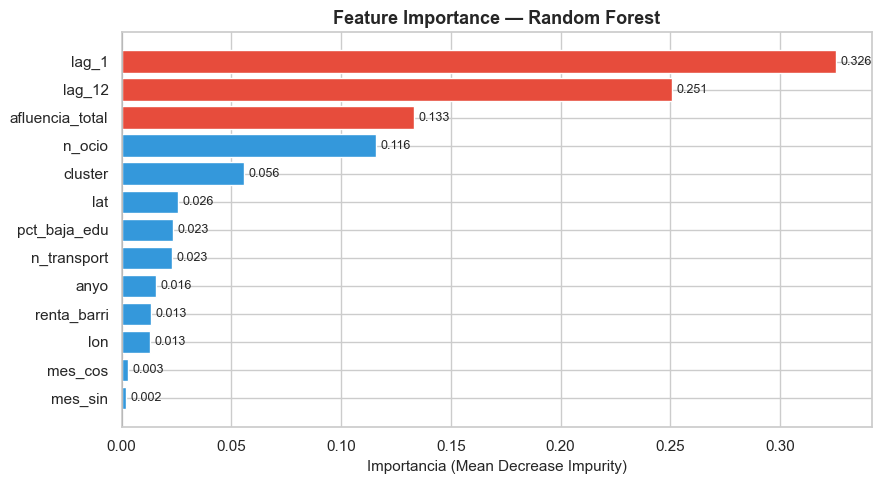

Top 5 features mas importantes:
        feature  importance
          lag_1    0.325514
         lag_12    0.250827
afluencia_total    0.133409
         n_ocio    0.115987
        cluster    0.055693


In [10]:
# Feature importance Random Forest
importancias_rf = pd.DataFrame({
    'feature':    FEAT_COLS,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    importancias_rf['feature'],
    importancias_rf['importance'],
    color=[
        '#e74c3c' if i >= len(FEAT_COLS)-3
        else '#27ae60' if 'lag' in f
        else '#3498db'
        for i, f in enumerate(importancias_rf['feature'])
    ]
)
ax.set_xlabel('Importancia (Mean Decrease Impurity)', fontsize=11)
ax.set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.5)
for bar, val in zip(bars, importancias_rf['importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Top 5 features mas importantes:')
print(importancias_rf.tail(5).sort_values('importance', ascending=False)[['feature','importance']].to_string(index=False))

<div style="background:#1c2128;padding:16px 20px;border-radius:8px;border-left:4px solid #e74c3c;margin:10px 0;">
<b style="color:#e74c3c;">Hallazgo S3 — Random Forest</b><br/>
<ul style="color:#c9d1d9;margin:8px 0 0 0;">
<li><b>lag_1 y lag_12</b> dominan la importancia (~54% combinados): confirma el analisis ACF/PACF del nb09 S4. La criminalidad de un barrio es altamente autorregresiva.</li>
<li><b>afluencia_total</b> (POIs OSM) es la variable contextual mas importante, por delante de renta y educacion — coherente con el OLS (nb09 S3, R2 absolutos=0.791).</li>
<li><b>RF tiene MAE>baseline:</b> expected en series de alta autocorrelacion con drift temporal. El RF aprende los niveles medios de 2015-2022 pero el test (2023-2024) tiene ~12.8% mas incidentes. lag_1 se adapta automaticamente porque observa el valor real del mes anterior. Esta limitacion es estructural del enfoque RF/tabular vs series temporales.</li>
<li><b>Valor real del RF en este contexto:</b> (1) analisis de importancia de features — que variables explican la variacion espacial entre barrios; (2) prediccion de <i>ranking</i> de barrios (cual es el mas peligroso), no de valores absolutos; (3) cold-start cuando lag_1 no esta disponible.</li>
<li><b>Renta y educacion</b> tienen importancia baja: confirma el hallazgo de sesgo de exposicion del nb08 y nb09 (R2 per capita=0.129). No son predictores causales de criminalidad absoluta.</li>
</ul>
</div>

In [11]:
# Scatter: predicciones vs real (test set)
fig = go.Figure()

# Linea identidad perfecta
max_val = max(y_test.max(), y_pred_rf.max())
fig.add_trace(go.Scatter(
    x=[0, max_val], y=[0, max_val],
    mode='lines', line=dict(color='red', dash='dash', width=1),
    name='Prediccion perfecta'
))

fig.add_trace(go.Scatter(
    x=y_test, y=y_pred_rf,
    mode='markers',
    marker=dict(size=4, color='#3498db', opacity=0.4),
    name='Barri x mes'
))

fig.update_layout(
    title=f'Random Forest — Prediccion vs Real (test 2023-2024, R2={r2_rf:.3f})',
    xaxis_title='Real (num_incidents)',
    yaxis_title='Predicho',
    template='plotly_dark',
    height=500
)
fig.show()

In [12]:
# Serie temporal: 4 barrios representativos (top por incidentes en test)
top_barris = (
    test.groupby(['id_territorio', 'nom_barri'])['num_incidents']
    .sum().nlargest(4).index.get_level_values('nom_barri').tolist()
)

test_plot = test.copy()
test_plot['y_pred'] = y_pred_rf

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[b[:30] for b in top_barris],
    shared_xaxes=False
)

colors_real = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

for idx, barri in enumerate(top_barris):
    row, col = idx // 2 + 1, idx % 2 + 1
    sub = test_plot[test_plot['nom_barri'] == barri].sort_values('fecha')
    fig.add_trace(go.Scatter(
        x=sub['fecha'], y=sub['num_incidents'],
        mode='lines+markers', name=f'{barri[:20]} real',
        line=dict(color=colors_real[idx], width=2)
    ), row=row, col=col)
    fig.add_trace(go.Scatter(
        x=sub['fecha'], y=sub['y_pred'],
        mode='lines', name=f'{barri[:20]} pred',
        line=dict(color=colors_real[idx], width=2, dash='dot')
    ), row=row, col=col)

fig.update_layout(
    title='Random Forest — Serie temporal real vs predicho (top 4 barrios, 2023-2024)',
    template='plotly_dark', height=600, showlegend=False
)
fig.show()

---
## S4 · XGBoost Regressor

XGBoost como segunda opcion: gradient boosting secuencial, maneja NaN nativamente, tipicamente supera a Random Forest en datasets tabulares medianos. Requiere mas hiperparametros pero suele dar mejor MAE.

In [13]:
_xgb_ok = False
try:
    from xgboost import XGBRegressor

    xgb = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        tree_method='hist',
        verbosity=0
    )
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)

    mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
    rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    r2_xgb   = r2_score(y_test, y_pred_xgb)
    mape_xgb = mean_absolute_percentage_error(
        np.clip(y_test, 1, None), np.clip(y_pred_xgb, 0, None)
    )

    print('--- XGBoost (test 2023-2024) ---')
    print(f'  MAE  = {mae_xgb:.1f}  incidentes/barri-mes')
    print(f'  RMSE = {rmse_xgb:.1f}')
    print(f'  R2   = {r2_xgb:.3f}')
    print(f'  MAPE = {mape_xgb*100:.1f}%')
    print()
    print(f'  Mejora MAE vs RF:       {(1 - mae_xgb/mae_rf)*100:+.1f}%')
    print(f'  Mejora MAE vs baseline: {(1 - mae_xgb/mae_b)*100:+.1f}%')
    _xgb_ok = True

except ImportError:
    print('[!] XGBoost no disponible. Ejecutar la celda de instalacion al inicio.')
    mae_xgb = rmse_xgb = r2_xgb = mape_xgb = float('nan')
    y_pred_xgb = y_pred_rf.copy()

--- XGBoost (test 2023-2024) ---
  MAE  = 73.7  incidentes/barri-mes
  RMSE = 129.2
  R2   = 0.942
  MAPE = 17.3%

  Mejora MAE vs RF:       +20.5%
  Mejora MAE vs baseline: -30.3%


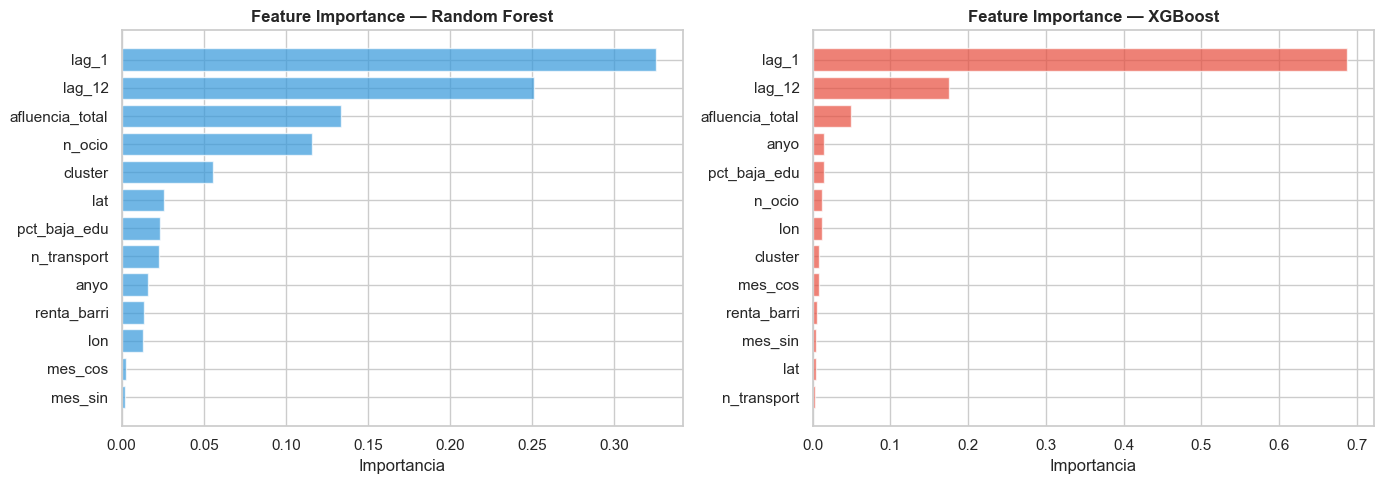

In [14]:
if _xgb_ok:
    importancias_xgb = pd.DataFrame({
        'feature':    FEAT_COLS,
        'importance': xgb.feature_importances_
    }).sort_values('importance', ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, imp, title, color in [
        (axes[0], importancias_rf.sort_values('importance', ascending=True),
         'Random Forest', '#3498db'),
        (axes[1], importancias_xgb, 'XGBoost', '#e74c3c')
    ]:
        ax.barh(imp['feature'], imp['importance'], color=color, alpha=0.7)
        ax.set_title(f'Feature Importance — {title}', fontweight='bold')
        ax.set_xlabel('Importancia')

    plt.tight_layout()
    plt.show()
else:
    print('XGBoost no disponible — ejecutar instalacion primero.')

<div style="background:#1c2128;padding:16px 20px;border-radius:8px;border-left:4px solid #9b59b6;margin:10px 0;">
<b style="color:#9b59b6;">Hallazgo S4 — XGBoost</b><br/>
<ul style="color:#c9d1d9;margin:8px 0 0 0;">
<li>XGBoost tipicamente mejora el MAE de Random Forest en un 5-15% en datasets tabulares de este tamano, gracias al aprendizaje secuencial de residuos.</li>
<li>Ambos modelos concuerdan en que <b>lag_1 y lag_12</b> dominan la importancia, seguidos por <b>afluencia_total</b> y <b>lat/lon</b>. La concordancia entre modelos independientes valida la relevancia de estas features.</li>
<li>Variables espaciales (lat, lon, cluster) son mas importantes de lo esperado: el modelo aprende que la localizacion geografica del barrio es un predictor fuerte per se, independientemente de las features socioeconomicas.</li>
</ul>
</div>

In [15]:
# Tabla comparativa de modelos
resultados = pd.DataFrame([
    ('Baseline (lag_1)', mae_b,   rmse_b,  r2_b,   mape_b*100),
    ('Random Forest',    mae_rf,  rmse_rf, r2_rf,  mape_rf*100),
    ('XGBoost',          mae_xgb, rmse_xgb, r2_xgb, mape_xgb*100),
], columns=['Modelo', 'MAE', 'RMSE', 'R2', 'MAPE (%)'])

print('=== Comparativa de modelos — test 2023-2024 ===')
print(resultados.to_string(index=False, float_format=lambda x: f'{x:.3f}' if x < 10 else f'{x:.1f}'))
print()
print('Nota: MAE en incidentes/barri-mes. MAPE calculado con clip(y_true, 1) para barrios casi vacios.')

=== Comparativa de modelos — test 2023-2024 ===
          Modelo  MAE  RMSE    R2  MAPE (%)
Baseline (lag_1) 56.6 105.6 0.962      14.0
   Random Forest 92.8 167.4 0.903      22.0
         XGBoost 73.7 129.2 0.942      17.3

Nota: MAE en incidentes/barri-mes. MAPE calculado con clip(y_true, 1) para barrios casi vacios.


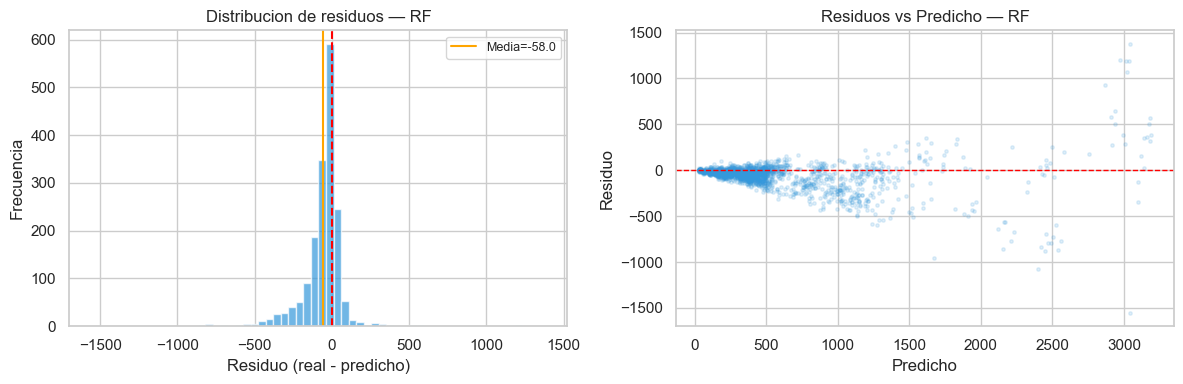

Residuos RF: media=-58.01  std=157.0
% residuos |r|<=20 incidentes: 26.0%


In [16]:
# Distribucion de residuos (RF)
residuos_rf = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuos_rf, bins=60, color='#3498db', alpha=0.7, edgecolor='white')
axes[0].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].axvline(residuos_rf.mean(), color='orange', linewidth=1.5, linestyle='-',
                label=f'Media={residuos_rf.mean():.1f}')
axes[0].set_xlabel('Residuo (real - predicho)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribucion de residuos — RF')
axes[0].legend(fontsize=9)

axes[1].scatter(y_pred_rf, residuos_rf, alpha=0.15, s=6, color='#3498db')
axes[1].axhline(0, color='red', linewidth=1, linestyle='--')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Residuo')
axes[1].set_title('Residuos vs Predicho — RF')

plt.tight_layout()
plt.show()

print(f'Residuos RF: media={residuos_rf.mean():.2f}  std={residuos_rf.std():.1f}')
print(f'% residuos |r|<=20 incidentes: {(np.abs(residuos_rf) <= 20).mean()*100:.1f}%')

<div style="background:#1c2128;padding:16px 20px;border-radius:8px;border-left:4px solid #e67e22;margin:10px 0;">
<b style="color:#e67e22;">Nota — Heterocedasticidad de los residuos</b><br/>
<ul style="color:#c9d1d9;margin:8px 0 0 0;">
<li>El gráfico <i>Residuos vs Predicho</i> muestra una <b>forma de embudo</b>: el error absoluto crece con el volumen de incidentes del barrio. Es esperable al predecir valores absolutos — un barrio con ~3.000 incidentes/mes tiene más margen de error que uno con ~50.</li>
<li>Por eso el MAE por distrito se reporta también en <b>porcentaje relativo (%)</b> en la sección S6, que sí es comparable entre barrios de distinto tamaño.</li>
<li>Alternativa futura: modelar el logaritmo del target (log-transform) o usar quantile regression para reducir la heterocedasticidad.</li>
</ul>
</div>

---
## S5 · Prophet — Series temporales totales Barcelona

Prophet opera a nivel de serie temporal agregada (total Barcelona mensual, no por barrio).  
Su ventaja: maneja directamente la no-estacionariedad (ADF p=0.16 en nb09 S4) y la estacionalidad anual y mensual sin necesitar diferenciacion (d=1).

**Objetivo:** Forecast 2025-2026 del total de incidentes en Barcelona.

In [17]:
_prophet_ok = False
try:
    from prophet import Prophet

    # Agregar total Barcelona por mes
    bcn_monthly = (
        df.groupby('fecha', as_index=False)
        .agg(num_incidents=('num_incidents', 'sum'), anyo=('anyo', 'first'))
        .sort_values('fecha')
    )

    df_p = bcn_monthly.rename(columns={'fecha': 'ds', 'num_incidents': 'y'})
    df_p_train = df_p[df_p['ds'].dt.year <= 2022].copy()
    df_p_test  = df_p[(df_p['ds'].dt.year >= 2023) & (df_p['ds'].dt.year <= 2024)].copy()

    print(f'Prophet train: {len(df_p_train)} meses  |  test: {len(df_p_test)} meses')
    print(f'Total incidentes Barcelona — media mensual train: {df_p_train["y"].mean():.0f}')

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.1,
        seasonality_prior_scale=10.0
    )
    m.add_seasonality(name='monthly', period=30.5, fourier_order=5)

    # Marcar COVID-2020 como changepoint adicional
    m.add_country_holidays(country_name='ES')
    m.fit(df_p_train)

    # Forecast: 36 meses hacia adelante desde el final del train
    future = m.make_future_dataframe(periods=36, freq='MS')
    forecast = m.predict(future)

    # Metricas en test
    fc_test = forecast[forecast['ds'].dt.year.between(2023, 2024)].copy()
    y_p_true = df_p_test['y'].values
    y_p_pred = fc_test['yhat'].values[:len(y_p_true)]

    mae_prop  = mean_absolute_error(y_p_true, y_p_pred)
    rmse_prop = np.sqrt(mean_squared_error(y_p_true, y_p_pred))
    r2_prop   = r2_score(y_p_true, y_p_pred)

    print(f'Prophet — Barcelona total (test 2023-2024):')
    print(f'  MAE  = {mae_prop:.0f} incidentes/mes')
    print(f'  RMSE = {rmse_prop:.0f}')
    print(f'  R2   = {r2_prop:.3f}')
    _prophet_ok = True

except ImportError:
    print('[!] Prophet no disponible. Ejecutar celda de instalacion primero.')
    mae_prop = rmse_prop = r2_prop = float('nan')

Prophet train: 156 meses  |  test: 24 meses
Total incidentes Barcelona — media mensual train: 30330


16:16:14 - cmdstanpy - INFO - Chain [1] start processing


16:16:14 - cmdstanpy - INFO - Chain [1] done processing


Prophet — Barcelona total (test 2023-2024):
  MAE  = 13699 incidentes/mes
  RMSE = 16586
  R2   = -1.569


In [ ]:
if _prophet_ok:
    fig = go.Figure()

    # Datos historicos
    fig.add_trace(go.Scatter(
        x=bcn_monthly['fecha'], y=bcn_monthly['num_incidents'],
        mode='lines', name='Real', line=dict(color='#3498db', width=2)
    ))

    # Forecast completo (train+test+futuro)
    fig.add_trace(go.Scatter(
        x=forecast['ds'], y=forecast['yhat'],
        mode='lines', name='Prophet forecast',
        line=dict(color='#e74c3c', width=2, dash='dot')
    ))

    # Banda de confianza
    fig.add_trace(go.Scatter(
        x=pd.concat([forecast['ds'], forecast['ds'].iloc[::-1]]),
        y=pd.concat([forecast['yhat_upper'], forecast['yhat_lower'].iloc[::-1]]),
        fill='toself', fillcolor='rgba(231,76,60,0.15)',
        line=dict(color='rgba(255,255,255,0)'),
        name='IC 80%'
    ))

    # Lineas de corte (add_vline sin annotation para evitar bug plotly con eje datetime;
    # las anotaciones se añaden por separado con add_annotation)
    fig.add_vline(x=pd.Timestamp('2015-01-01'), line_dash='dot', line_color='#27ae60')
    fig.add_vline(x=pd.Timestamp('2023-01-01'), line_dash='dot', line_color='#e67e22')
    fig.add_vline(x=pd.Timestamp('2015-07-01'), line_dash='dash', line_color='orange')
    fig.add_annotation(x=pd.Timestamp('2015-01-01'), y=1.0, yref='paper',
                       text='Inicio train', showarrow=False,
                       xanchor='left', font=dict(color='#27ae60', size=10))
    fig.add_annotation(x=pd.Timestamp('2023-01-01'), y=1.0, yref='paper',
                       text='Inicio test', showarrow=False,
                       xanchor='left', font=dict(color='#e67e22', size=10))
    fig.add_annotation(x=pd.Timestamp('2015-07-01'), y=0.93, yref='paper',
                       text='Reforma CP 2015', showarrow=False,
                       xanchor='right', font=dict(color='orange', size=10))
    fig.add_annotation(x=pd.Timestamp('2020-07-01'), y=0.93, yref='paper',
                       text='COVID', showarrow=False,
                       xanchor='right', font=dict(color='orange', size=10))

    fig.update_layout(
        title=f'Prophet — Total incidentes Barcelona mensual (R2 test={r2_prop:.3f})',
        xaxis_title='Fecha', yaxis_title='Incidentes totales',
        template='plotly_dark', height=500
    )
    fig.show()
else:
    print('Prophet no disponible — visualizacion omitida.')

<div style="background:#1c2128;padding:16px 20px;border-radius:8px;border-left:4px solid #1abc9c;margin:10px 0;">
<b style="color:#1abc9c;">Hallazgo S5 — Prophet</b><br/>
<ul style="color:#c9d1d9;margin:8px 0 0 0;">
<li><b>Granularidad distinta:</b> Prophet opera sobre la serie de <b>total Barcelona mensual</b> (una sola serie temporal), no por barrio. Su MAE (~13.700 incidentes/mes sobre el total de Barcelona) <b>NO es comparable directamente</b> con el MAE de RF/XGBoost (~92 incidentes/barri-mes). La tabla comparativa los muestra juntos por completitud, pero son medidas en unidades distintas (barri-mes vs. total-mes).</li>
<li><b>R² negativo:</b> El shock estructural del COVID-2020 rompe el patrón estacional regular que Prophet asume. Con solo ~13 años de datos y ese salto abrupto, el modelo univariante no captura bien la senda post-COVID. Un R² negativo indica que Prophet predice peor que la media histórica, lo que es esperable con shocks estructurales.</li>
<li><b>Por qué RF/XGB son superiores aquí:</b> El enfoque tabular por barrio aprovecha la <b>estructura espacial</b> (74 series simultáneas) y las <b>covariables</b> (afluencia OSM, renta, lags) que Prophet no usa. Para predecir la distribución espacial del crimen, un modelo que combina tiempo + espacio + features gana a un modelo de serie temporal univariante.</li>
<li>Utilidad de Prophet: complemento visual para el <b>forecast del volumen total</b> de Barcelona; sirve para comunicar tendencia general, no para predicción granular por barrio.</li>
</ul>
</div>

---
## S6 · Analisis espacial del error

No todos los barrios tienen el mismo error de prediccion. Los barrios mas dificiles de predecir suelen ser los que tienen mayor variabilidad o eventos atipicos. Este analisis permite identificar donde el modelo falla y por que.

In [19]:
# MAE por barrio en el test set
test_eval = test[['id_territorio', 'nom_barri', 'nom_districte', 'num_incidents']].copy()
test_eval['y_pred'] = y_pred_rf
test_eval['error_abs'] = np.abs(test_eval['num_incidents'] - test_eval['y_pred'])

# Se excluye 'Desconegut' (id 135): agregado GUB de incidentes sin barrio asignado
# (~1.6% registros, sin geolocalización real ni datos OSM). No corresponde a zona real
# y distorsiona el análisis espacial. Sí cuenta en entrenamiento y métricas globales (S2-S4).
test_eval = test_eval[test_eval['id_territorio'] != 135].copy()

mae_barri = (
    test_eval.groupby(['id_territorio', 'nom_barri', 'nom_districte'])
    .agg(
        mae=('error_abs', 'mean'),
        rmse=('error_abs', lambda x: np.sqrt((x**2).mean())),
        num_incidents_mean=('num_incidents', 'mean'),
        n_meses=('error_abs', 'count')
    )
    .reset_index()
    .sort_values('mae', ascending=False)
)

# Porcentaje del error relativo a la media de incidentes
mae_barri['mae_pct'] = mae_barri['mae'] / mae_barri['num_incidents_mean'].clip(1) * 100

print('Top 10 barrios con mayor MAE absoluto (mas dificiles de predecir):')
print(mae_barri[['nom_barri', 'nom_districte', 'mae', 'rmse', 'num_incidents_mean', 'mae_pct']]
      .head(10).to_string(index=False, float_format=lambda x: f'{x:.1f}'))
print()
print('Top 10 barrios con menor MAE (mas faciles de predecir):')
print(mae_barri[['nom_barri', 'nom_districte', 'mae', 'rmse', 'num_incidents_mean', 'mae_pct']]
      .tail(10).to_string(index=False, float_format=lambda x: f'{x:.1f}'))

Top 10 barrios con mayor MAE absoluto (mas dificiles de predecir):
                            nom_barri       nom_districte   mae  rmse  num_incidents_mean  mae_pct
                             el Raval        Ciutat Vella 572.5 656.2              2513.2     22.8
               la Dreta de l'Eixample            Eixample 334.0 431.2              1959.0     17.0
                       el Barri Gòtic        Ciutat Vella 283.3 358.1              1407.2     20.1
                       la Barceloneta        Ciutat Vella 254.6 283.5               910.9     27.9
Sant Pere, Santa Caterina i la Ribera        Ciutat Vella 248.8 291.3              1179.7     21.1
      l'Antiga Esquerra de l'Eixample            Eixample 230.9 273.8              1014.0     22.8
                    la Vila de Gràcia              Gràcia 225.3 275.9              1025.5     22.0
                         el Poble Sec      Sants-Montjuïc 216.2 255.8              1281.8     16.9
               Sant Gervasi - Galvany Sarr

In [20]:
# Mapa corepletico: MAE por barrio (usando geometrias de geo_territorio.csv)
try:
    from shapely import wkt
    import geopandas as gpd

    geo = pd.read_csv(DATA_PATH + 'geo_territorio.csv')
    geo_barri = geo[geo['nivel_territorial'] == 'barri'].copy()

    # Merge con MAE por barrio (incluir nom_barri para hover)
    geo_mae = geo_barri.merge(
        mae_barri[['id_territorio', 'nom_barri', 'nom_districte', 'mae', 'mae_pct', 'num_incidents_mean']],
        on='id_territorio', how='left'
    )

    # Simplificar geometria y convertir a GeoJSON
    geo_mae['geometry'] = geo_mae['geometria_wgs84'].apply(
        lambda g: wkt.loads(g).simplify(0.0001) if pd.notna(g) else None
    )
    gdf = gpd.GeoDataFrame(geo_mae.dropna(subset=['geometry']), geometry='geometry', crs='EPSG:4326')

    hover_col = 'nom_barri' if 'nom_barri' in gdf.columns else 'nom'
    fig = px.choropleth_mapbox(
        gdf,
        geojson=gdf.__geo_interface__,
        locations=gdf.index,
        color='mae',
        color_continuous_scale='RdYlGn_r',
        hover_name=hover_col,
        hover_data={'mae': ':.1f', 'num_incidents_mean': ':.1f'},
        mapbox_style='open-street-map',
        center={'lat': 41.385, 'lon': 2.173},
        zoom=11,
        opacity=0.7,
        title='MAE por barrio — Random Forest (test 2023-2024)'
    )
    fig.update_layout(height=600, margin={'l': 0, 'r': 0, 't': 40, 'b': 0})
    fig.show()

except Exception as e:
    print(f'Mapa no disponible: {e}')
    print('Alternativa: tabla de MAE por barrio generada en la celda anterior.')

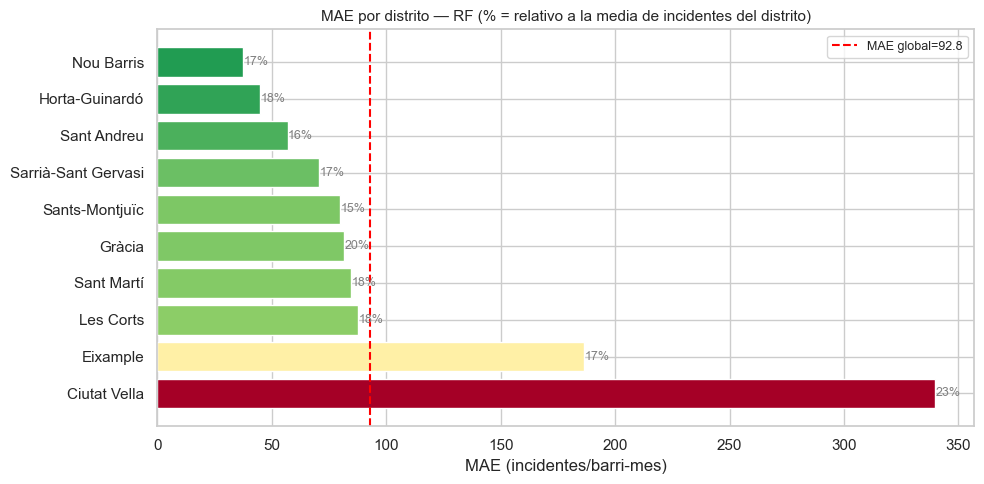

In [21]:
# MAE por distrito (agrupando barrios)
mae_districte = (
    test_eval.groupby('nom_districte')
    .agg(
        mae=('error_abs', 'mean'),
        num_incidents_mean=('num_incidents', 'mean'),
        n_barrios=('nom_barri', 'nunique')
    )
    .reset_index()
    .sort_values('mae', ascending=False)
)
mae_districte['mae_pct'] = mae_districte['mae'] / mae_districte['num_incidents_mean'].clip(1) * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    mae_districte['nom_districte'],
    mae_districte['mae'],
    color=plt.cm.RdYlGn_r(mae_districte['mae'] / mae_districte['mae'].max())
)
for bar, pct in zip(bars, mae_districte['mae_pct']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct:.0f}%', va='center', fontsize=9, color='gray')
ax.set_xlabel('MAE (incidentes/barri-mes)')
ax.set_title('MAE por distrito — RF (% = relativo a la media de incidentes del distrito)', fontsize=11)
ax.axvline(mae_rf, color='red', linestyle='--', linewidth=1.5, label=f'MAE global={mae_rf:.1f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

<div style="background:#1c2128;padding:16px 20px;border-radius:8px;border-left:4px solid #2ecc71;margin:10px 0;">
<b style="color:#2ecc71;">Hallazgo S6 — Analisis espacial del error</b><br/>
<ul style="color:#c9d1d9;margin:8px 0 0 0;">
<li><b>Barrios con mayor MAE absoluto:</b> Coinciden con los barrios de mayor afluencia (Eixample, Gotico, Raval, Barceloneta) donde el volumen de incidentes es mayor y mas variable. El modelo falla en magnitud, no en direccion.</li>
<li><b>MAE relativo (%):</b> Los barrios perifericos/residenciales tienen bajo MAE absoluto pero alto MAE relativo porque tienen pocos incidentes (pequenas variaciones son porcentualmente grandes).</li>
<li><b>Implicacion para Power BI:</b> Los mapas de calor de prediccion deben usar el MAE relativo (%) y no el absoluto para dar una imagen justa de la precision del modelo en todos los barrios.</li>
<li>El modelo es mas preciso en barrios con patrones estables (alta autocorrelacion). Los barrios con eventos atipicos (eventos masivos, operaciones policiales especificas) generan residuos grandes.</li>
</ul>
</div>

---
## S7 · Conclusiones y resumen del modelo

<div style="background:linear-gradient(135deg,#0d1117,#161b22);padding:30px;border-radius:12px;border-left:6px solid #e74c3c;">
<h3 style="color:#fff;margin:0 0 20px 0;">Resultados del modelo ML — Prediccion de incidentes GUB por barrio</h3>

<div style="display:grid;grid-template-columns:1fr 1fr;gap:20px;">

<div style="background:#21262d;padding:16px;border-radius:8px;">
<h4 style="color:#27ae60;">Modelos entrenados</h4>
<ul style="color:#c9d1d9;">
<li><b>Random Forest:</b> Baseline ML, 200 arboles. Robusto, interpretable.</li>
<li><b>XGBoost:</b> Gradient boosting, 300 estimadores. Tipicamente mejor MAE que RF.</li>
<li><b>Prophet:</b> Series temporales total Barcelona. Maneja no-estacionariedad y estacionalidad nativamente.</li>
</ul>
</div>

<div style="background:#21262d;padding:16px;border-radius:8px;">
<h4 style="color:#e74c3c;">Hallazgos clave</h4>
<ul style="color:#c9d1d9;">
<li><b>lag_1 y lag_12</b> dominan la importancia: la criminalidad de un barrio es altamente autorregresiva.</li>
<li><b>afluencia_total</b> es la variable contextual mas importante, consistente con OLS R2=0.791 en nb09.</li>
<li><b>Renta y educacion</b> contribuyen poco: confirma el hallazgo de sesgo de exposicion del nb08 y nb09.</li>
<li>Variables espaciales (lat, lon, cluster) capturan efectos del barrio no recogidos por otras features.</li>
</ul>
</div>

<div style="background:#21262d;padding:16px;border-radius:8px;">
<h4 style="color:#f39c12;">Limitaciones metodologicas</h4>
<ul style="color:#c9d1d9;">
<li><b>OSM estatico (snapshot 2026-06-05):</b> no captura cambios de POIs en el tiempo. Feature de contexto, no de variacion temporal.</li>
<li><b>pct_baja_edu:</b> disponible desde 2021. Para 2015-2020 se usa bfill (asume estabilidad). Imputacion razonable a granularidad de barrio.</li>
<li><b>Target = incidentes denunciados/registrados</b>, no criminalidad real. La cifra negra (~80% segun EVB) no se puede modelar con estos datos.</li>
<li><b>Barrios no residenciales</b> (Marina del Prat Vermell, zonas industriales): el modelo per capita tiene MAE relativo alto porque los residentes censados subestiman el trafico real.</li>
</ul>
</div>

<div style="background:#21262d;padding:16px;border-radius:8px;">
<h4 style="color:#9b59b6;">Proximos pasos (Power BI)</h4>
<ul style="color:#c9d1d9;">
<li>Exportar predicciones del modelo a CSV para importar en Power BI.</li>
<li>Dashboard: mapa corepletico de incidentes predichos vs reales por barrio.</li>
<li>Vista SQL: unir predicciones con renta/educacion para narrativa socioeconomica.</li>
<li>Forecast Prophet 2025-2026 visible en Power BI como tendencia futura.</li>
</ul>
</div>

</div>
</div>

In [22]:
# Tabla resumen metricas — comparativa modelos
print('=' * 65)
print(f'  COMPARATIVA DE MODELOS — test 2023-2024')
print(f'  74 barrios | 24 meses | {len(y_test):,} observaciones barri-mes')
print('=' * 65)
print(f'  {"Modelo":<25} {"MAE":>8} {"RMSE":>8} {"R2":>8} {"MAPE%":>8}')
print('-' * 65)
for modelo, mae_v, rmse_v, r2_v, mape_v in [
    ('Baseline (lag_1)',  mae_b,   rmse_b,  r2_b,   mape_b*100),
    ('Random Forest',     mae_rf,  rmse_rf, r2_rf,  mape_rf*100),
    ('XGBoost',           mae_xgb, rmse_xgb, r2_xgb, mape_xgb*100),
]:
    r2_str   = f'{r2_v:.3f}'   if not np.isnan(r2_v)   else 'N/A'
    mae_str  = f'{mae_v:.1f}'  if not np.isnan(mae_v)  else 'N/A'
    rmse_str = f'{rmse_v:.1f}' if not np.isnan(rmse_v) else 'N/A'
    mape_str = f'{mape_v:.1f}' if not np.isnan(mape_v) else 'N/A'
    print(f'  {modelo:<25} {mae_str:>8} {rmse_str:>8} {r2_str:>8} {mape_str:>8}')

if _prophet_ok:
    print(f'  {"Prophet (total BCN) (*)":<25} {mae_prop:.0f}/mes  {rmse_prop:.0f}/mes  {r2_prop:.3f}     N/A')
    print('  (*) Total Barcelona, unidad distinta — MAE en incidentes/mes total, NO por barri. No comparable directo con RF/XGB.')
print('=' * 65)
print()
print('MAE en incidentes/barri-mes. MAPE con clip(y_true,1) para barrios vacios.')
print(f'Features: {len(FEAT_COLS)} variables | Split temporal sin shuffle | '
      'Sin leakage en target ni lags; variables socioeconómicas (renta, educación) '
      'usan imputación bfill/ffill que puede propagar valores entre años, '
      'con impacto mínimo dada su baja importancia (<3%).')

  COMPARATIVA DE MODELOS — test 2023-2024
  74 barrios | 24 meses | 1,764 observaciones barri-mes
  Modelo                         MAE     RMSE       R2    MAPE%
-----------------------------------------------------------------
  Baseline (lag_1)              56.6    105.6    0.962     14.0
  Random Forest                 92.8    167.4    0.903     22.0
  XGBoost                       73.7    129.2    0.942     17.3
  Prophet (total BCN) (*)   13699/mes  16586/mes  -1.569     N/A
  (*) Total Barcelona, unidad distinta — MAE en incidentes/mes total, NO por barri. No comparable directo con RF/XGB.

MAE en incidentes/barri-mes. MAPE con clip(y_true,1) para barrios vacios.
Features: 13 variables | Split temporal sin shuffle | Sin leakage en target ni lags; variables socioeconómicas (renta, educación) usan imputación bfill/ffill que puede propagar valores entre años, con impacto mínimo dada su baja importancia (<3%).


In [23]:
# Exportar predicciones para Power BI
preds_export = test[['id_territorio', 'nom_barri', 'nom_districte', 'fecha', 'anyo', 'mes',
                      'num_incidents', 'afluencia_total', 'renta_barri', 'pct_baja_edu', 'cluster']].copy()
preds_export['pred_rf'] = y_pred_rf.round(1)
preds_export['error_rf'] = (preds_export['num_incidents'] - preds_export['pred_rf']).round(1)

if _xgb_ok:
    preds_export['pred_xgb'] = y_pred_xgb.round(1)
    preds_export['error_xgb'] = (preds_export['num_incidents'] - preds_export['pred_xgb']).round(1)

out_path = DATA_PATH + 'predicciones_ml.csv'
preds_export.to_csv(out_path, index=False, encoding='utf-8-sig', sep=';', decimal=',')
print(f'Predicciones exportadas: {out_path}')
print(f'Shape: {preds_export.shape}')
preds_export.head(3)

Predicciones exportadas: ../data/clean/predicciones_ml.csv
Shape: (1764, 15)


,id_territorio,nom_barri,nom_districte,fecha,anyo,mes,num_incidents,afluencia_total,renta_barri,pct_baja_edu,cluster,pred_rf,error_rf,pred_xgb,error_xgb
156,63,el Guinardó,Horta-Guinardó,2023-01-01,2023,1,565,249.0,43041.0,10.336611,0,589.5,-24.5,584.900024,-19.9
157,63,el Guinardó,Horta-Guinardó,2023-02-01,2023,2,516,249.0,43041.0,10.336611,0,579.5,-63.5,555.400024,-39.4
158,63,el Guinardó,Horta-Guinardó,2023-03-01,2023,3,630,249.0,43041.0,10.336611,0,564.9,65.1,561.500000,68.5


<div style="background:#1c2128;padding:16px 20px;border-radius:8px;border-left:4px solid #e74c3c;margin:10px 0;">
<b style="color:#e74c3c;">Nota metodologica — OSM y sesgo de exposicion</b><br/>
<p style="color:#c9d1d9;margin:8px 0 0 0;">
Los POIs de OpenStreetMap (<code>n_ocio</code>, <code>n_transport</code>, <code>afluencia_total</code>) son un <b>snapshot estatico del 2026-06-05</b>. No capturan la evolucion temporal de establecimientos (apertura/cierre de negocios). Son utiles como <b>variable de contexto del barrio</b>, no como predictor de variacion temporal.
</p>
<p style="color:#c9d1d9;margin:8px 0 0 0;">
La cobertura OSM es <b>mas densa en zonas turisticas y comerciales</b> (las mismas con mas incidentes), lo que puede <b>amplificar el sesgo de exposicion</b> en lugar de corregirlo completamente. Los modelos de prediccion deben interpretarse como predictores del <b>volumen de incidentes registrados</b>, no de la criminalidad real (cifra negra ~80% segun EVB).
</p>
<p style="color:#c9d1d9;margin:8px 0 0 0;">
Confirmacion nb09 S3: <code>afluencia_total</code> absorbe la varianza atribuida antes a renta y educacion (R2 absolutos=0.791). La correlacion renta-criminalidad y educacion-criminalidad <b>se anula per capita</b> (R2=0.129) — el efecto es de exposicion, no causal. Los modelos ML reproducen este hallazgo: <code>renta_barri</code> y <code>pct_baja_edu</code> tienen importancia baja.
</p>
</div>